# Frequentist Logistic Regression Baseline

This notebook fits a standard logistic regression baseline for the telco churn data. Its purpose is to provide an interpretable frequentist comparison for the Bayesian hierarchical model, not to replace the Bayesian analysis.

The final report uses this baseline to make an honest comparison: prediction is very similar between the frequentist and Bayesian models, so the Bayesian model's main contribution is uncertainty-aware inference and partial pooling rather than a large accuracy gain.

**How to run:** run the notebook from the project root. The data file is expected at `data/WA_Fn-UseC_-Telco-Customer-Churn.csv`.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score

## Setup

Import data manipulation, plotting, logistic regression, and evaluation utilities.


In [4]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Load the Raw Data

Read the same telco churn CSV used in the Bayesian notebook. Keeping the data source identical makes the baseline comparison fair.


In [6]:
# Convert TotalCharges to numeric and remove rows where it is blank
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")

# Drop customerID and missing rows
df = df.drop(columns=["customerID"]).dropna().copy()

# Encode response
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Convert some binary variables to 0/1
binary_cols = ["Partner", "Dependents", "PaperlessBilling", "PhoneService"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)

# Use Yes vs not-Yes for these service features
service_cols = ["OnlineSecurity", "TechSupport"]
for col in service_cols:
    df[col] = (df[col] == "Yes").astype(int)

df.shape

(7032, 20)

## Clean and Encode the Data

The cleaning steps match the Bayesian notebook: remove blank `TotalCharges` rows, drop `customerID`, encode `Churn`, and convert selected yes/no variables to numeric indicators.


In [8]:
X = pd.DataFrame({
    "tenure": df["tenure"].astype(float),
    "MonthlyCharges": df["MonthlyCharges"].astype(float),
    "SeniorCitizen": df["SeniorCitizen"].astype(float),
    "Partner": df["Partner"].astype(float),
    "Dependents": df["Dependents"].astype(float),
    "PaperlessBilling": df["PaperlessBilling"].astype(float),
    "OnlineSecurity": df["OnlineSecurity"].astype(float),
    "TechSupport": df["TechSupport"].astype(float),
})

# Add categorical variables using one-hot encoding
X = pd.concat([
    X,
    pd.get_dummies(df["InternetService"], prefix="InternetService", drop_first=True, dtype=float),
    pd.get_dummies(df["PaymentMethod"], prefix="PaymentMethod", drop_first=True, dtype=float),
    pd.get_dummies(df["Contract"], prefix="Contract", drop_first=True, dtype=float),
], axis=1)

y = df["Churn"].astype(int)

X.head()

,tenure,MonthlyCharges,SeniorCitizen,Partner,Dependents,PaperlessBilling,OnlineSecurity,TechSupport,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year
0,1.0,29.85,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,34.0,56.95,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,2.0,53.85,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,45.0,42.30,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.0,70.70,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Build the Frequentist Design Matrix

This baseline uses the same customer-level predictors as the Bayesian model. Unlike the Bayesian model, contract type is included as ordinary fixed-effect dummy variables rather than as a hierarchical intercept.


In [10]:
continuous_cols = ["tenure", "MonthlyCharges"]

for col in continuous_cols:
    X[col] = (X[col] - X[col].mean()) / X[col].std()

## Standardize Continuous Predictors

Tenure and monthly charges are standardized before fitting. This matches the Bayesian model and makes coefficient magnitudes easier to compare.


In [12]:
X_with_const = sm.add_constant(X)

model = sm.Logit(y, X_with_const)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.419972
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7032
Model:                          Logit   Df Residuals:                     7016
Method:                           MLE   Df Model:                           15
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2747
Time:                        13:10:39   Log-Likelihood:                -2953.2
converged:                       True   LL-Null:                       -4071.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.2856      

## Fit Logistic Regression

Fit a maximum-likelihood logistic regression using `statsmodels`. The printed summary gives coefficient estimates, standard errors, z-statistics, and p-values.


In [14]:
conf_int = result.conf_int()

freq_summary = pd.DataFrame({
    "parameter": result.params.index,
    "estimate": result.params.values,
    "std_error": result.bse.values,
    "p_value": result.pvalues.values,
    "ci_lower": conf_int[0].values,
    "ci_upper": conf_int[1].values
})

freq_summary = freq_summary.sort_values("estimate")
freq_summary

,parameter,estimate,std_error,p_value,ci_lower,ci_upper
15,Contract_Two year,-1.319591,0.174128,3.501561e-14,-1.660875,-0.978306
0,const,-1.285640,0.133477,5.862955e-22,-1.547250,-1.024030
1,tenure,-0.776073,0.054446,4.235934e-46,-0.882786,-0.669361
10,InternetService_No,-0.766658,0.154007,6.421608e-07,-1.068505,-0.464811
14,Contract_One year,-0.658419,0.105687,4.667433e-10,-0.865562,-0.451277
7,OnlineSecurity,-0.454182,0.085390,1.043963e-07,-0.621544,-0.286820
8,TechSupport,-0.387454,0.088071,1.085851e-05,-0.560071,-0.214838
5,Dependents,-0.182826,0.089097,4.016922e-02,-0.357452,-0.008200
11,PaymentMethod_Credit card (automatic),-0.082116,0.113330,4.687122e-01,-0.304238,0.140006
13,PaymentMethod_Mailed check,-0.024420,0.112885,8.287344e-01,-0.245670,0.196831


## Coefficient Summary

This table reorganizes the fitted model output into a report-friendly format with estimates, standard errors, p-values, and 95% confidence intervals.


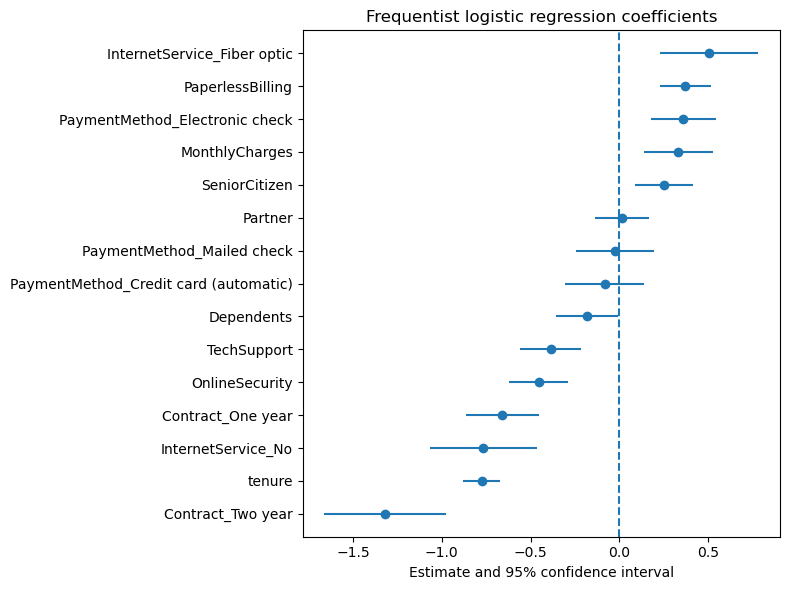

In [16]:
plot_df = freq_summary[freq_summary["parameter"] != "const"].copy()

y_pos = np.arange(len(plot_df))

plt.figure(figsize=(8, 6))
plt.errorbar(
    plot_df["estimate"],
    y_pos,
    xerr=[
        plot_df["estimate"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["estimate"]
    ],
    fmt="o"
)
plt.axvline(0, linestyle="--")
plt.yticks(y_pos, plot_df["parameter"])
plt.xlabel("Estimate and 95% confidence interval")
plt.title("Frequentist logistic regression coefficients")
plt.tight_layout()
plt.show()

## Coefficient Interval Plot

The plot visualizes which predictors are estimated to increase or decrease churn log-odds under the frequentist model. It is useful as a visual baseline for the Bayesian posterior interval plot.


In [18]:
p_hat = result.predict(X_with_const)
y_hat = (p_hat >= 0.5).astype(int)

metrics = pd.DataFrame({
    "accuracy_at_0.5": [accuracy_score(y, y_hat)],
    "brier_score": [brier_score_loss(y, p_hat)],
    "log_loss": [log_loss(y, p_hat)],
    "roc_auc": [roc_auc_score(y, p_hat)]
})

metrics

,accuracy_at_0.5,brier_score,log_loss,roc_auc
0,0.79963,0.136752,0.419972,0.842445


## In-Sample Predictive Metrics

These metrics are computed on the same data used for fitting, so they should be interpreted as model-fit summaries rather than out-of-sample validation. The Bayesian model achieves nearly identical in-sample performance, which is why the report frames the Bayesian contribution as inferential rather than predictive.


## Baseline Takeaways

The frequentist model confirms the same broad story as the Bayesian model: tenure, online security, tech support, and longer contracts are associated with lower churn, while monthly charges, paperless billing, fiber optic service, and electronic check payment are associated with higher churn.

The baseline is strong and interpretable. The Bayesian model is preferred in the final analysis because it adds posterior uncertainty summaries and a principled hierarchical treatment of contract-level baseline churn risk.
